# 11 — QA ディスカッション・マスター（20 シナリオ索引）

**目的:** お客様との技術 QA に耐える **シナリオ × 理論 × 数式 × パラメータ × 実装** の索引。

---

## 使い方

1. 下の **全 20 シナリオ表** で論点を特定  
2. **症状 → パラメータ** トリアージで第一アクションを決める  
3. 詳細は Part Notebook（07–10）の各 Scenario へ  
4. 数式の前提は [00_theory](./00_theory_grf_mpc_wbc.ipynb)

---

## 3 層 × 数式（おさらい）

| Layer | 変数 | 代表式 |
|-------|------|--------|
| L1 Gait | $s_i(k)$, $v^{ref}$ | $T_{stance}=duty/f_{step}$ |
| L2 MPC | $\mathbf{u}=[F_1,\ldots,F_4]$ | $m\dot{v}=\sum F_i+mg$, $\|F_t\|\le\mu F_z$ |
| L3 WBC | $\boldsymbol{\tau}$ | $\boldsymbol{\tau}=J^\top F^*$ (stance) |

---

## 路面 × 勾配 × 速度 — 難易度マトリクス

| 路面 | 勾配 | 3 kph | 5 kph | 7 kph |
|------|------|-------|-------|-------|
| flat | 0 | ◎ | ◎ | ○ |
| boxes / perlin | 0 | ○ | △ | ✕ |
| bumpy_flat | 0 | ○ | △ (resilient) | ✕ |
| bumpy_uphill | +0.08 rad | △ | △ (resilient) | ✕ |
| bumpy_downhill | −0.08 rad | △ | ✕→△ (resilient) | ✕ |

◎=容易 △=要チューニング ✕=本 workshop 範囲外

---

## 上り → 下り パラメータ切替（Scenario 16）

| パラメータ | bumpy_flat | bumpy_uphill | bumpy_downhill |
|------|------------|--------------|----------------|
| mu | 0.42 | 0.38 | **0.35** |
| step_freq | 1.20 | 1.10 | **1.05** |
| duty | 0.76 | 0.78 | **0.82** |
| ref_z_scale | 1.07 | 1.08 | **1.10** |
| speed_ramp_s | 18 | 20 | **22** |

**反対方向の誤適用 (Sc13):** 下り preset を上りに使う → 加速不足。上り preset を下りに → 制動不足・転倒増。

---


In [1]:
import sys
from pathlib import Path

# mpc_dog ルートを sys.path に追加
ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "scripts" / "pympc_lab.py").exists():
        ROOT = p
        break
sys.path.insert(0, str(ROOT / "scripts"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pympc_lab import (
    TUNING_GUIDE,
    apply_preset,
    compare_runs,
    load_param_study,
    load_preset_yaml,
    plot_friction_cone,
    run_flat_sim,
    run_speed_terrain_sim,
    run_speed_terrain_sim_resilient,
)

from tuning_labs import (
    TUNING_LABS,
    list_labs,
    run_lab,
    run_lab_pair,
    plot_speed_trial_journey,
    plot_param_study_mu,
    load_cached_lab_results,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4)
print(f"repo: {ROOT}")

from scenario_labs import (
    SCENARIO_LABS,
    compare_preset_table,
    run_scenario,
    run_scenario_pair,
    scenario_table,
)


repo: /home/takuya/work/mpc_dog


## 全 20 シナリオ索引

In [2]:
import pandas as pd
from scenario_labs import scenario_table

df = pd.DataFrame(scenario_table())
display(df[["num", "id", "title", "category", "terrain", "speed_kph", "slope", "difficulty"]])


,num,id,title,category,terrain,speed_kph,slope,difficulty
0,1,sc01_flat_mu_ice,低μ平坦 — 摩擦円錐が支配する,flat,flat（チェッカー平坦）,NaN,flat,basic
1,2,sc02_flat_aggressive_gait,平坦・攻め gait — horizon 内の支持周期,flat,flat,NaN,flat,basic
2,3,sc03_flat_ref_z_low,ref_z 不足 — SRB 高さ参照の下限,flat,flat,NaN,flat,basic
3,4,sc04_flat_duty_low,duty 不足 — 支持脚が足りない,flat,flat,NaN,flat,intermediate
4,5,sc05_flat_grf_max,grf_max 過大 — 垂直力ソフト制限,flat,flat,NaN,flat,intermediate
5,6,sc06_boxes_s2_gait_fail,箱地形 × Session2 gait — 地形持ち込み失敗,rough,random_boxes（離散段差）,NaN,flat + 箱,intermediate
6,7,sc07_perlin_mu_high,Perlin × 高μ — 連続起伏での過信,rough,perlin（連続起伏）,NaN,flat + 起伏,intermediate
7,8,sc08_perlin_foothold_off,足場 opt OFF — 地形モデル不一致の切り分け,rough,perlin,NaN,flat + 起伏,intermediate
8,9,sc09_bumpy_3kph,凸凹平坦 3 kph — 速度を下げた no-fall,speed,bumpy_flat（Perlin heightfield）,3.0,flat + 凸凹,intermediate
9,10,sc10_bumpy_5kph_no_fall_fail,凸凹 5 kph no-fall — 距離 ~4 m で失敗,speed,bumpy_flat,5.0,flat + 凸凹,advanced


## 症状 → 第一パラメータ（トリアージ）

| 症状 | 数式上の意味 | 第一 | 第二 | 第三 |
|------|-------------|------|------|------|
| 即転倒（数 step） | $F_z$ / 支持不足 | ref_z↑ | step_freq↓ | μ↓ |
| 横滑り・足刺さり | $\|F_t\|>\mu F_z$ | μ↓ | duty↑ | grf_max↓ |
| 加速しない | $\sum F_{ix}$ 不足 | μ↑※ | speed_ramp↓ | grf_max↑ |
| 跳ね・関節飽和 | $F_z^{max}$ 過大 | grf_max↓ | ref_z↓ | swing gain↓ |
| 上りで停滞 | $F_{ix}<mg\sin\theta$ | μ↑※ | freq↓ | ramp↑ |
| 下りで加速暴走 | 制動 $F_{ix}$ 不足 | duty↑ | μ↓ | ramp↑ |
| 不整地で変な足 | foothold 不一致 | opt OFF で比較 | 地形推定 | freq↓ |

※ μ↑ は転倒リスクとトレードオフ

---

## よくある QA（20 シナリオ横断）

### Q1. MPC の μ と sim 地面摩擦の違いは？
**A:** MPC μ は **計画時の摩擦円錐**（Layer 2 制約）。sim 摩擦は MuJoCo 接触。不一致だと「計画通りに蹴れない」。

### Q2. なぜ GRF を直接 MPC するのか？
**A:** 12 関節より **12D GRF** の方が $\|F_t\|\le\mu F_z$ を自然に入れられる（Scenario 01, 07）。

### Q3. resilient 20 m の意味は？
**A:** no-fall 不可でも **gait/μ/ramp の学習** に有効。falls 数も必ず報告（Sc19）。

### Q4. 5 kph は何が厳しいのか？
**A:** $v^{ref}$↑ → $|F_{ix}|$ 要求↑。凸凹で $F_z^{min}$ 違反しやすい（Sc09–12）。

### Q5. 下りが最難な理由は？
**A:** $mg\sin\theta$ が加速方向 + 制動 GRF も摩擦円錐内 → duty↑ μ↓ ramp↑（Sc12, 14）。

### Q6. 上りから下りへ preset をそのまま使える？
**A:** **不可**。θ 符号で必要 $F_{ix}$ が逆（Sc13, 16）。

### Q7. step_freq と duty の使い分けは？
**A:** freq↓=MPC 解の時間的余裕。duty↑=支持時間・$F_z$ 配分（Sc04, 14）。

### Q8. speed_ramp_s の理論的効果は？
**A:** $dv^{ref}/dt$ のピーク↓ → $|F_{ix}|$ スパイク↓（Sc15）。

### Q9. ref_z はいつ上げる？
**A:** 勾配変化・ toe collision 時（Sc18）。下りは 1.10 まで。

### Q10. ADAS 操舵 MPC との対応は？
**A:** SRB≈車両、GRF≈タイヤ力、μ≈路面、WBC≈ステア/サス下位（Sc20）。

---

## Notebook 相互参照

| Part | Notebook | Scenarios |
|------|----------|-----------|
| 0 | [00_theory](./00_theory_grf_mpc_wbc.ipynb) | 数式基礎 |
| 1 | [07_scenarios_flat_foundation](./07_scenarios_flat_foundation.ipynb) | 01–05 |
| 2 | [08_scenarios_rough_speed](./08_scenarios_rough_speed.ipynb) | 06–10 |
| 3 | [09_scenarios_slope_ramp](./09_scenarios_slope_ramp.ipynb) | 11–15 |
| 4 | [10_scenarios_transition_limits](./10_scenarios_transition_limits.ipynb) | 16–20 |
| — | [06_mpc_tuning_journey](./06_mpc_tuning_journey.ipynb) | Phase 1–4 labs |


In [3]:
# Session 4 勝者パラメータ（Sc11–12, 19 と対応）
import pandas as pd
from pympc_lab import load_speed_winners

winners = load_speed_winners()
rows = []
for scene, w in winners.items():
    r = w["result"]
    rows.append({
        "scene": scene,
        "mu": w["mu"],
        "step_freq": w["step_freq"],
        "duty": w["duty_factor"],
        "ramp_s": w["speed_ramp_s"],
        "distance_m": round(r["distance_m"], 1),
        "falls": r["falls"],
        "mean_kph": round(r["mean_kph"], 2),
    })
display(pd.DataFrame(rows))


,scene,mu,step_freq,duty,ramp_s,distance_m,falls,mean_kph
0,bumpy_flat,0.42,1.20,0.76,18.0,20.0,17,1.12
1,bumpy_uphill,0.38,1.10,0.78,20.0,20.0,16,1.06
2,bumpy_downhill,0.35,1.05,0.82,22.0,20.0,24,0.47


In [4]:
# preset YAML 3 地形比較（Sc16）
from scenario_labs import compare_preset_table
import pandas as pd

display(pd.DataFrame(compare_preset_table([
    "session04_bumpy_uphill",
    "session04_bumpy_flat",
    "session04_bumpy_downhill",
])))


,preset,scene,mu,step_freq,duty_factor,ref_z_scale,speed_ramp_s,target_kph
0,session04_bumpy_uphill,bumpy_uphill,0.38,1.10,0.78,1.08,20.0,5.0
1,session04_bumpy_flat,bumpy_flat,0.42,1.20,0.76,1.07,18.0,5.0
2,session04_bumpy_downhill,bumpy_downhill,0.35,1.05,0.82,1.10,22.0,5.0


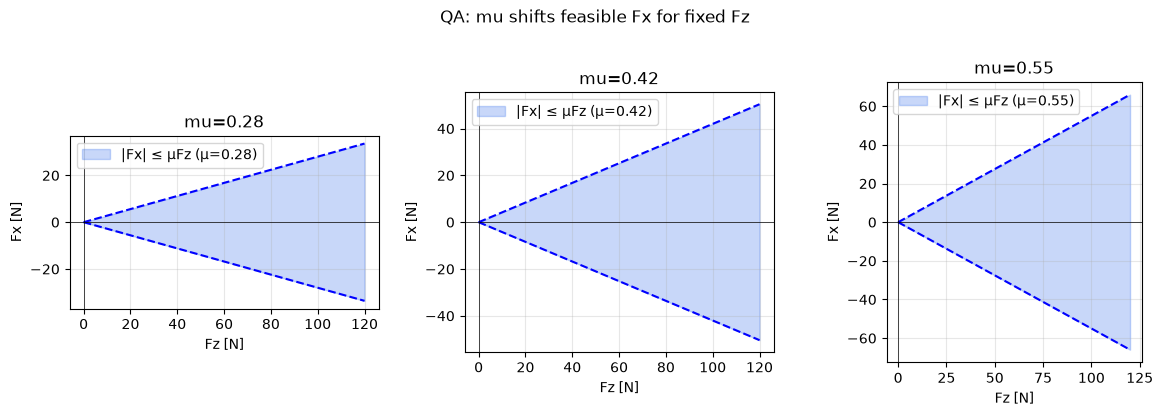

In [5]:
# 摩擦円錐: μ の違い（議論用）
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, mu in zip(axes, [0.28, 0.42, 0.55]):
    plot_friction_cone(mu=mu, f_max=120, ax=ax)
    ax.set_title(f"mu={mu}")
fig.suptitle("QA: mu shifts feasible Fx for fixed Fz", y=1.02)
plt.tight_layout()


## ディスカッション進行案（90 分）

| 時間 | 内容 |
|------|------|
| 0–15 | 00_theory おさらい + 本表で Sc 選定 |
| 15–45 | Part 07–08 から 4 シナリオ深掘り（お客様関心順） |
| 45–70 | Part 09–10 勾配・遷移（Sc13, 16 必須） |
| 70–90 | QA 10 問 + 勝ち YAML diff |

---

## 修了チェック

- [ ] 20 シナリオから **任意 3 つ** を数式付きで説明できる  
- [ ] 上り→下りで **変えるパラメータリスト** を即答できる  
- [ ] fail 症状から **第一パラメータ** を 3 つ提案できる  
- [ ] `scenario_labs.py` / `tuning_labs.py` CLI で再現できる  
